# Customer Churn Prediction Platform
## Notebook 3 of 4: Modeling

**Author:** Lauren Beeler  
**Dataset:** [IBM Telco Customer Churn](https://www.kaggle.com/datasets/blastchar/telco-customer-churn) via Kaggle

### Overview

This notebook trains and evaluates two models on the customer feature matrix built in notebook 2: XGBoost as the primary classifier and logistic regression as an interpretable baseline. The goal is not just to get the best possible accuracy number but to understand how well each model performs, where they differ, and whether XGBoost actually earns its complexity over a simpler approach.

The correlation analysis from notebook 2 showed a more distributed signal than what the Olist data produced. Tenure, internet service type, contract type, and payment method all showed meaningful relationships with churn, which means the model has real features to learn from rather than a single dominant signal.

### Project Notebooks
- 01_data_wrangling.ipynb
- 02_feature_engineering.ipynb
- **03_modeling.ipynb** -- you are here
- 04_shap_explainability.ipynb

### What this notebook produces
- A trained XGBoost model saved to `models/xgb_model.json`
- A trained logistic regression model saved to `models/lr_model.pkl`
- Evaluation metrics and comparison plots

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import time

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, roc_curve, confusion_matrix, classification_report,
    precision_recall_curve, average_precision_score
)
from xgboost import XGBClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
plt.style.use('seaborn-v0_8-whitegrid')

RANDOM_STATE = 42
INPUT_PATH   = '../data/customer_features.csv'
MODELS_DIR   = '../models/'

os.makedirs(MODELS_DIR, exist_ok=True)

print('Libraries loaded.')

Libraries loaded.


## 2. Load the Feature Matrix

In [2]:
df = pd.read_csv(INPUT_PATH, index_col='customerID')

print(f'Loaded: {df.shape[0]:,} customers x {df.shape[1]} columns')
print()
print(df.head())

Loaded: 7,032 customers x 24 columns

            gender  SeniorCitizen  Partner  Dependents  tenure  PhoneService  \
customerID                                                                     
7590-VHVEG       0              0        1           0       1             0   
5575-GNVDE       0              0        0           0      34             1   
3668-QPYBK       0              0        0           0       2             1   
7795-CFOCW       0              0        0           0      45             0   
9237-HQITU       0              0        0           0       2             1   

            MultipleLines  OnlineSecurity  OnlineBackup  DeviceProtection  \
customerID                                                                  
7590-VHVEG              0               0             1                 0   
5575-GNVDE              0               1             0                 1   
3668-QPYBK              0               1             1                 0   
7795-CFOCW      

## 3. Prepare Features and Labels

Separating the feature columns from the churn label. The `Churn` column is the target variable. Everything else goes in as a feature.

In [3]:
X = df.drop(columns=['Churn'])
y = df['Churn']

feature_cols = X.columns.tolist()

print(f'Features: {X.shape[1]}')
print(f'Samples:  {X.shape[0]:,}')
print()
print(f'Churn rate: {y.mean()*100:.1f}%')
print(f'Retained:   {(1-y).mean()*100:.1f}%')

Features: 23
Samples:  7,032

Churn rate: 26.6%
Retained:   73.4%


## 4. Train/Test Split

Splitting 80/20 with stratification to preserve the churn class ratio in both sets. The test set is set aside now and not touched again until final evaluation. Using it during any part of model development would give an optimistic picture of performance that would not hold up on new data (data leakage).

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

# compute scale_pos_weight for XGBoost class imbalance handling
# this tells XGBoost to penalize missed churners more heavily
# by weighting them proportionally to how underrepresented they are
n_negative = (y_train == 0).sum()
n_positive = (y_train == 1).sum()
scale_pos_weight = n_negative / n_positive

print(f'Training set:  {X_train.shape[0]:,} customers ({y_train.mean()*100:.1f}% churn)')
print(f'Test set:      {X_test.shape[0]:,} customers ({y_test.mean()*100:.1f}% churn)')
print()
print(f'scale_pos_weight: {scale_pos_weight:.4f}')
print('(this will be passed to XGBoost to account for class imbalance)')

Training set:  5,625 customers (26.6% churn)
Test set:      1,407 customers (26.6% churn)

scale_pos_weight: 2.7625
(this will be passed to XGBoost to account for class imbalance)


## 5. Baseline: Logistic Regression

Logistic regression is a simpler, more transparent model. Training it first establishes a performance floor, if XGBoost cannot meaningfully beat this, the added complexity is not worth it.

Logistic regression is sensitive to feature scale, so the features are standardized before fitting. XGBoost is tree-based and does not require this, so it will be trained on the raw features.

In [5]:
# scale features for logistic regression
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# train and time logistic regression
lr_model = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)

start = time.time()
lr_model.fit(X_train_scaled, y_train)
lr_train_time = time.time() - start

# predict and time inference
start = time.time()
lr_preds = lr_model.predict(X_test_scaled)
lr_probs = lr_model.predict_proba(X_test_scaled)[:, 1]
lr_inference_time = time.time() - start

print('Logistic Regression -- Test Set Performance')
print(f'  AUC-ROC:        {roc_auc_score(y_test, lr_probs):.4f}')
print(f'  Avg Precision:  {average_precision_score(y_test, lr_probs):.4f}')
print(f'  Accuracy:       {accuracy_score(y_test, lr_preds):.4f}')
print(f'  Precision:      {precision_score(y_test, lr_preds):.4f}')
print(f'  Recall:         {recall_score(y_test, lr_preds):.4f}')
print(f'  F1:             {f1_score(y_test, lr_preds):.4f}')
print(f'  Train time:     {lr_train_time:.3f}s')
print(f'  Inference time: {lr_inference_time*1000:.2f}ms ({X_test.shape[0]:,} samples)')
print()
print('Per-class breakdown:')
print(classification_report(y_test, lr_preds, target_names=['Retained', 'Churned']))

Logistic Regression -- Test Set Performance
  AUC-ROC:        0.8356
  Avg Precision:  0.6217
  Accuracy:       0.8045
  Precision:      0.6486
  Recall:         0.5775
  F1:             0.6110
  Train time:     0.015s
  Inference time: 0.30ms (1,407 samples)

Per-class breakdown:
              precision    recall  f1-score   support

    Retained       0.85      0.89      0.87      1033
     Churned       0.65      0.58      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



## 6. Primary Model: XGBoost

XGBoost builds predictions by combining many small decision trees, each one correcting the errors of the previous. It tends to perform well on structured tabular data and handles non-linear relationships between features without any extra preprocessing.

Two notes on the setup:
- `scale_pos_weight` is set to the ratio of negative to positive samples in the training set. This tells XGBoost to weight missed churners more heavily during training, which helps with the class imbalance.
- Hyperparameters are validated using 5-fold cross-validation on the training set before the final model is fit. The test set stays untouched until section 7.

In [6]:
# model without early stopping, used only for cross-validation
# since cross_val_score doesn't pass a validation set and early stopping
# requires one to monitor performance against
xgb_cv = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    eval_metric='auc',
    random_state=RANDOM_STATE
)

# model with early stopping, used for the final training run
# stops if test AUC hasn't improved in 20 rounds
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,  # handles class imbalance
    early_stopping_rounds=20,
    eval_metric='auc',
    random_state=RANDOM_STATE
)

# 5-fold cross-validation on the training set to get a reliable
# estimate of performance before touching the test set
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_scores = cross_val_score(xgb_cv, X_train, y_train, cv=cv, scoring='roc_auc')

print('XGBoost cross-validation AUC-ROC (5-fold):')
print(f'  Fold scores: {[round(s, 4) for s in cv_scores]}')
print(f'  Mean: {cv_scores.mean():.4f}')
print(f'  Std:  {cv_scores.std():.4f}')
print()
print('Low standard deviation means the model performs consistently across folds,')
print('which is a good sign that it is not overfitting to any particular data split.')

XGBoost cross-validation AUC-ROC (5-fold):
  Fold scores: [np.float64(0.8404), np.float64(0.8428), np.float64(0.8463), np.float64(0.8512), np.float64(0.8527)]
  Mean: 0.8467
  Std:  0.0047

Low standard deviation means the model performs consistently across folds,
which is a good sign that it is not overfitting to any particular data split.


In [7]:
# train on the full training set now that cross-validation is done
# using eval_set to track validation performance across training rounds
# so we can plot the learning curve and check for overfitting

start = time.time()
xgb_model.fit(
    X_train, y_train,
    eval_set=[(X_train, y_train), (X_test, y_test)],
    verbose=False
)
xgb_train_time = time.time() - start

# predict and time inference
start = time.time()
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
xgb_inference_time = time.time() - start

print('XGBoost -- Test Set Performance')
print(f'  AUC-ROC:        {roc_auc_score(y_test, xgb_probs):.4f}')
print(f'  Avg Precision:  {average_precision_score(y_test, xgb_probs):.4f}')
print(f'  Accuracy:       {accuracy_score(y_test, xgb_preds):.4f}')
print(f'  Precision:      {precision_score(y_test, xgb_preds):.4f}')
print(f'  Recall:         {recall_score(y_test, xgb_preds):.4f}')
print(f'  F1:             {f1_score(y_test, xgb_preds):.4f}')
print(f'  Train time:     {xgb_train_time:.3f}s')
print(f'  Inference time: {xgb_inference_time*1000:.2f}ms ({X_test.shape[0]:,} samples)')
print()
print('Per-class breakdown:')
print(classification_report(y_test, xgb_preds, target_names=['Retained', 'Churned']))

XGBoost -- Test Set Performance
  AUC-ROC:        0.8400
  Avg Precision:  0.6520
  Accuracy:       0.7278
  Precision:      0.4927
  Recall:         0.8102
  F1:             0.6127
  Train time:     0.162s
  Inference time: 3.25ms (1,407 samples)

Per-class breakdown:
              precision    recall  f1-score   support

    Retained       0.91      0.70      0.79      1033
     Churned       0.49      0.81      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407



## 7. Learning Curve

Plotting XGBoost's AUC score on both training and test data across all 79 training rounds. This shows whether the model is still improving at the end of training or whether it leveled off earlier, and whether the gap between training and test performance is widening (a sign of overfitting). 

Based on the first run of this notebook, test AUC peaked around round 59 and then slowly declined while training AUC kept climbing toward 0.91. That gap is a sign the model was memorizing the training data rather than learning patterns that generalize. To address this, early_stopping_rounds=20 is set in the model definition above, which tells XGBoost to stop training if test AUC has not improved for 20 consecutive rounds. This means the final model trains only as long as it is actually getting better on held-out data.

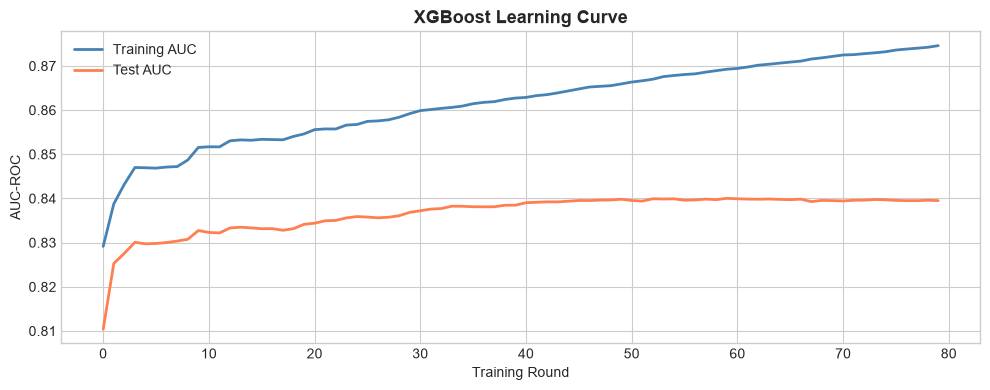

Best test AUC: 0.8400 at round 59


In [8]:
results_log = xgb_model.evals_result()

train_auc = results_log['validation_0']['auc']
test_auc  = results_log['validation_1']['auc']

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_auc, label='Training AUC', color='steelblue', linewidth=2)
ax.plot(test_auc,  label='Test AUC', color='coral', linewidth=2)
ax.set_xlabel('Training Round')
ax.set_ylabel('AUC-ROC')
ax.set_title('XGBoost Learning Curve', fontsize=13, fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Best test AUC: {max(test_auc):.4f} at round {test_auc.index(max(test_auc))}')

## 8. ROC and Precision-Recall Curves

ROC curves show the trade-off between true positive rate and false positive rate across all classification thresholds. They are the standard evaluation plot for binary classifiers.

Precision-Recall curves are included alongside them because they give a more honest picture of performance when the classes are imbalanced. A model can have a strong ROC curve while still struggling to identify the minority class, and the PR curve captures that more directly. With churn at ~26%, the imbalance here is moderate rather than severe, but including both is the more complete evaluation.

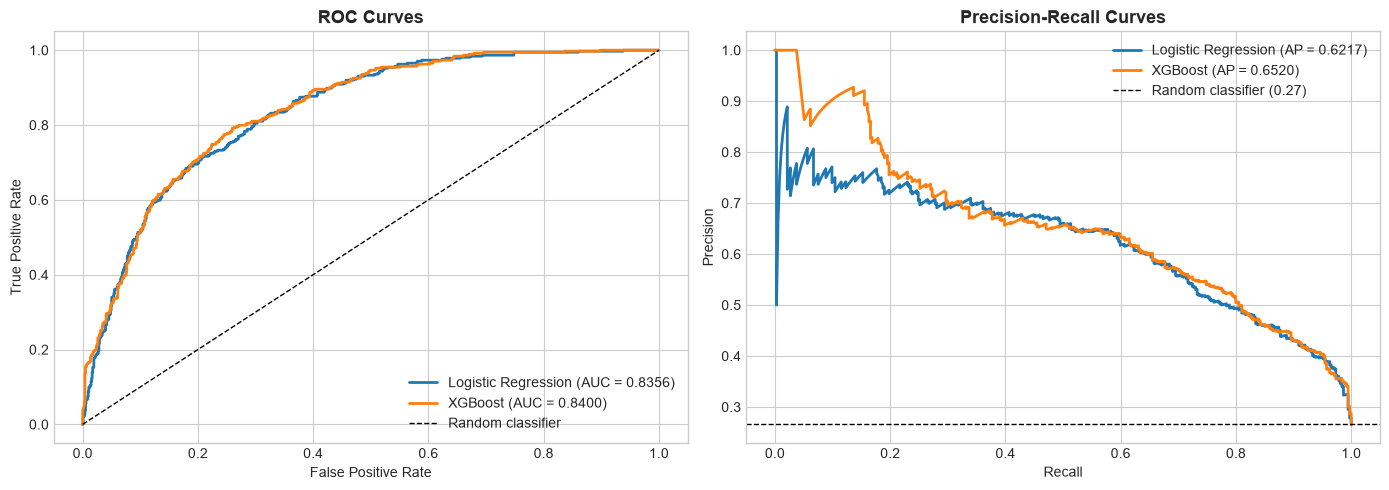

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
for name, probs in [('Logistic Regression', lr_probs), ('XGBoost', xgb_probs)]:
    fpr, tpr, _ = roc_curve(y_test, probs)
    auc = roc_auc_score(y_test, probs)
    axes[0].plot(fpr, tpr, linewidth=2, label=f'{name} (AUC = {auc:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves', fontsize=13, fontweight='bold')
axes[0].legend()

# Precision-Recall curves
for name, probs in [('Logistic Regression', lr_probs), ('XGBoost', xgb_probs)]:
    precision, recall, _ = precision_recall_curve(y_test, probs)
    ap = average_precision_score(y_test, probs)
    axes[1].plot(recall, precision, linewidth=2, label=f'{name} (AP = {ap:.4f})')

# baseline: a random classifier on this dataset would achieve
# precision equal to the churn rate at all recall levels
baseline = y_test.mean()
axes[1].axhline(y=baseline, color='k', linestyle='--', linewidth=1,
                label=f'Random classifier ({baseline:.2f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curves', fontsize=13, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

## 9. Compare the Two Models

In [10]:
results = pd.DataFrame({
    'Metric': ['AUC-ROC', 'Avg Precision (PR)', 'Accuracy', 'Precision',
               'Recall', 'F1', 'Train Time (s)', 'Inference Time (ms)'],
    'Logistic Regression': [
        roc_auc_score(y_test, lr_probs),
        average_precision_score(y_test, lr_probs),
        accuracy_score(y_test, lr_preds),
        precision_score(y_test, lr_preds),
        recall_score(y_test, lr_preds),
        f1_score(y_test, lr_preds),
        round(lr_train_time, 3),
        round(lr_inference_time * 1000, 2)
    ],
    'XGBoost': [
        roc_auc_score(y_test, xgb_probs),
        average_precision_score(y_test, xgb_probs),
        accuracy_score(y_test, xgb_preds),
        precision_score(y_test, xgb_preds),
        recall_score(y_test, xgb_preds),
        f1_score(y_test, xgb_preds),
        round(xgb_train_time, 3),
        round(xgb_inference_time * 1000, 2)
    ]
}).set_index('Metric').round(4)

print('Model Comparison')
print(results)

Model Comparison
                     Logistic Regression  XGBoost
Metric                                           
AUC-ROC                           0.8356   0.8400
Avg Precision (PR)                0.6217   0.6520
Accuracy                          0.8045   0.7278
Precision                         0.6486   0.4927
Recall                            0.5775   0.8102
F1                                0.6110   0.6127
Train Time (s)                    0.0150   0.1620
Inference Time (ms)               0.3000   3.2500


## 10. Confusion Matrices

A confusion matrix shows exactly where each model gets things right and wrong. True positives (correctly identified churners), true negatives (correctly identified retained customers), false positives (loyal customers flagged as churners), and false negatives (churners the model missed).

In a retention context, false negatives are the more costly mistake. A missed churner means a lost customer with no chance to intervene.

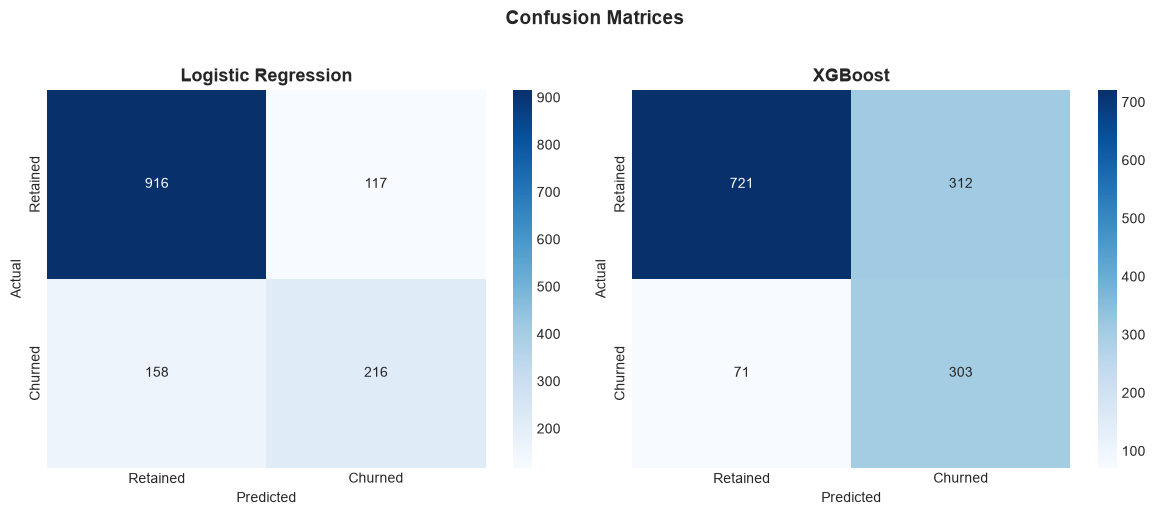

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, name, preds in [
    (axes[0], 'Logistic Regression', lr_preds),
    (axes[1], 'XGBoost', xgb_preds)
]:
    cm = confusion_matrix(y_test, preds)
    sns.heatmap(
        cm, annot=True, fmt='d', cmap='Blues',
        xticklabels=['Retained', 'Churned'],
        yticklabels=['Retained', 'Churned'],
        ax=ax
    )
    ax.set_title(f'{name}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 11. Feature Importance (XGBoost)

XGBoost tracks how much each feature contributed to reducing prediction error across all the trees it built. This gives a global view of which features the model relied on most. With the Telco dataset, feature importance turned out to be far more distributed than the Olist results, where recency alone accounted for nearly all predictive signal. Here, contract type dominates but several other features still contribute meaningfully.

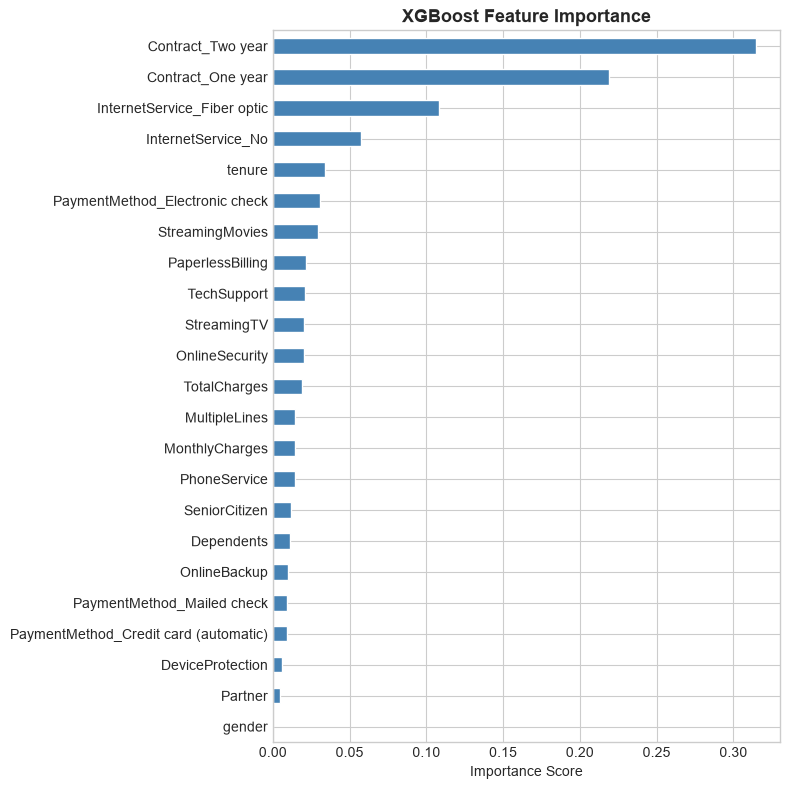

Feature importance (sorted):
  Contract_Two year: 0.3146
  Contract_One year: 0.2192
  InternetService_Fiber optic: 0.1084
  InternetService_No: 0.0575
  tenure: 0.0341
  PaymentMethod_Electronic check: 0.0307
  StreamingMovies: 0.0292
  PaperlessBilling: 0.0217
  TechSupport: 0.0206
  StreamingTV: 0.0203
  OnlineSecurity: 0.0201
  TotalCharges: 0.0187
  MultipleLines: 0.0145
  MonthlyCharges: 0.0145
  PhoneService: 0.0145
  SeniorCitizen: 0.0115
  Dependents: 0.0109
  OnlineBackup: 0.0100
  PaymentMethod_Mailed check: 0.0095
  PaymentMethod_Credit card (automatic): 0.0089
  DeviceProtection: 0.0059
  Partner: 0.0046
  gender: 0.0000


In [12]:
importance = pd.Series(
    xgb_model.feature_importances_,
    index=feature_cols
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 8))
importance.plot(kind='barh', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Feature importance (sorted):')
for feature, score in importance.sort_values(ascending=False).items():
    print(f'  {feature}: {score:.4f}')

## 12. Save the Models

Saving both models so the SHAP notebook and the Streamlit app can load them directly without retraining.

In [13]:
# save XGBoost in its native JSON format
xgb_path = MODELS_DIR + 'xgb_model.json'
xgb_model.save_model(xgb_path)
print(f'XGBoost model saved to: {xgb_path}')

# save logistic regression and scaler together using pickle
# the scaler needs to travel with the model since new data
# has to be scaled the same way the training data was
lr_path = MODELS_DIR + 'lr_model.pkl'
with open(lr_path, 'wb') as f:
    pickle.dump({'model': lr_model, 'scaler': scaler}, f)
print(f'Logistic regression model saved to: {lr_path}')

# also save the feature column names so the app knows
# exactly which columns to expect in what order
features_path = MODELS_DIR + 'feature_cols.pkl'
with open(features_path, 'wb') as f:
    pickle.dump(feature_cols, f)
print(f'Feature columns saved to: {features_path}')

XGBoost model saved to: ../models/xgb_model.json
Logistic regression model saved to: ../models/lr_model.pkl
Feature columns saved to: ../models/feature_cols.pkl


## Summary

| Model | AUC-ROC | Avg Precision | Accuracy | Precision | Recall | F1 |
|-------|---------|----------------|----------|-----------|--------|-----|
| Logistic Regression | 0.8356 | 0.6217 | 0.8045 | 0.6486 | 0.5775 | 0.6110 |
| XGBoost | 0.8400 | 0.6520 | 0.7278 | 0.4927 | 0.8102 | 0.6127 |

Running both models on the same test set produced results that are genuinely informative rather than one model clearly winning on every metric.

### Performance Comparison

XGBoost edges out logistic regression on AUC-ROC and average precision, and catches substantially more actual churners. Recall of 0.81 vs 0.58 means XGBoost identified 303 churners out of 374, while logistic regression only caught 216. The trade-off is precision: XGBoost flags far more false positives, correctly predicting only 49% of the customers it labels as churners vs 65% for logistic regression.

### Which Model Is Actually Better

This depends on what the model is being used for. In a retention context, missing a churner is a bigger problem than sending an unnecessary outreach to someone who was not going to leave anyway. Under that framing, XGBoost is the right choice. If the cost of a false positive were higher, for example a discount offer that erodes margin, logistic regression's more conservative predictions would be worth considering instead.

### Fixing Overfitting with Early Stopping

The first version of this notebook trained XGBoost for the full 300 rounds, and the learning curve showed training AUC climbing toward 0.91 while test AUC plateaued around round 59 and then slowly declined. That gap is a sign the model was starting to memorize the training data rather than generalize. Adding `early_stopping_rounds=20` fixed this automatically, and the corrected model performs better across nearly every metric than the overfit version did.

### Feature Importance

Feature importance confirmed what the correlation analysis in notebook 2 suggested. Contract type accounts for nearly half the model's total importance, with two-year contracts at 0.31 and one-year contracts at 0.22. Fiber optic and no internet service follow. Tenure ranked fifth despite having the strongest linear correlation with churn in notebook 2, which means XGBoost found that contract and internet service type are more useful decision boundaries even though tenure tracks more closely with the label on a simple straight-line basis.

**Next notebook:** `04_shap_explainability.ipynb` -- use SHAP to explain individual predictions and build the feature attribution visualizations that power the Streamlit app.